In [ ]:
import zipfile
import os
import cv2

zip_path = "archive.zip"
extract_path = "extracted_images"

# Extract the ZIP file
with zipfile.ZipFile(zip_path, "r") as zip_ref:
    zip_ref.extractall(extract_path)

# Read all images
images = []

for root, dirs, files in os.walk(extract_path):
    for file in files:
        if file.lower().endswith((".jpg", ".jpeg", ".png", ".bmp")):
            img_path = os.path.join(root, file)
            img = cv2.imread(img_path)

            if img is not None:
                images.append(img)

print("Total images loaded:", len(images))

Total images loaded: 100


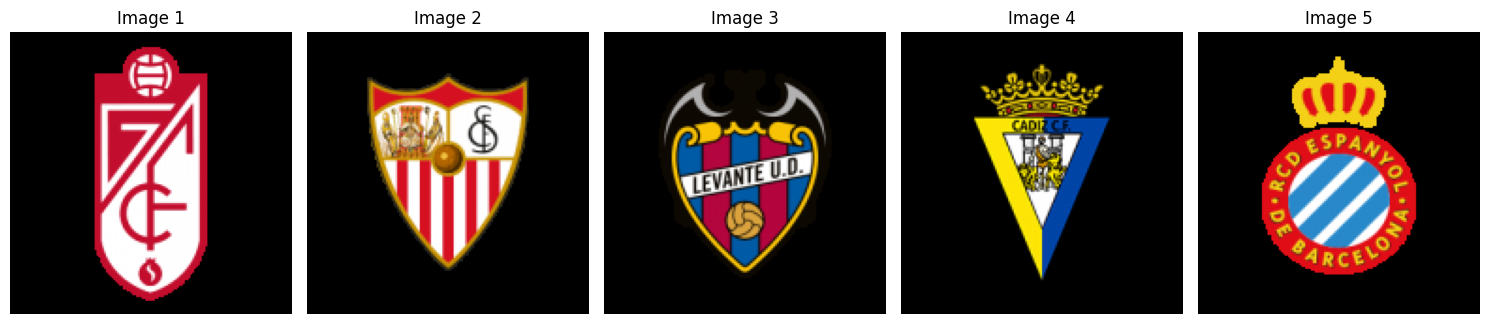

In [ ]:
import matplotlib.pyplot as plt


fig, axes = plt.subplots(1, 5, figsize=(15, 5))

for i, ax in enumerate(axes.flat):
    if i < len(images):

        img_rgb = cv2.cvtColor(images[i], cv2.COLOR_BGR2RGB)
        ax.imshow(img_rgb)
        ax.set_title(f'Image {i+1}')
        ax.axis('off')
    else:
        ax.axis('off')

plt.tight_layout()
plt.show()

In [ ]:
import pandas as pd


image_properties = []

for i, img in enumerate(images):
    height, width, channels = img.shape
    image_properties.append({
        'Image Index': i,
        'Height': height,
        'Width': width,
        'Channels': channels
    })


image_properties_df = pd.DataFrame(image_properties)


display(image_properties_df)

,Image Index,Height,Width,Channels
0,0,150,150,3
1,1,150,150,3
2,2,150,150,3
3,3,150,150,3
4,4,150,150,3
...,...,...,...,...
95,95,140,140,3
96,96,140,140,3
97,97,140,140,3
98,98,140,140,3


In [ ]:

target_size = (224, 224)


resized_images = []

for img in images:

    resized_img = cv2.resize(img, target_size, interpolation=cv2.INTER_AREA)
    resized_images.append(resized_img)

print(f"All images resized to {target_size}. Total resized images: {len(resized_images)}")


print("Shapes of the first 5 resized images:")
for i in range(min(5, len(resized_images))):
    print(f"Image {i+1}: {resized_images[i].shape}")

All images resized to (224, 224). Total resized images: 100
Shapes of the first 5 resized images:
Image 1: (224, 224, 3)
Image 2: (224, 224, 3)
Image 3: (224, 224, 3)
Image 4: (224, 224, 3)
Image 5: (224, 224, 3)


### Normalize pixel values from 0-255 to 0-1

In [ ]:
normalized_images = []

for img in resized_images:

    normalized_img = img.astype('float32') / 255.0
    normalized_images.append(normalized_img)

print(f"Converted {len(normalized_images)} images to normalized pixel values (0-1 range).")
print("Shape and value range of the first 5 normalized images:")
for i in range(min(5, len(normalized_images))):
    print(f"Image {i+1}: Shape {normalized_images[i].shape}, Min Value {normalized_images[i].min():.2f}, Max Value {normalized_images[i].max():.2f}")

Converted 100 images to normalized pixel values (0-1 range).
Shape and value range of the first 5 normalized images:
Image 1: Shape (224, 224, 3), Min Value 0.00, Max Value 1.00
Image 2: Shape (224, 224, 3), Min Value 0.00, Max Value 1.00
Image 3: Shape (224, 224, 3), Min Value 0.00, Max Value 1.00
Image 4: Shape (224, 224, 3), Min Value 0.00, Max Value 1.00
Image 5: Shape (224, 224, 3), Min Value 0.00, Max Value 1.00


### Install `imgaug` for Data Augmentation

In [ ]:
!pip install imgaug

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 948.0/948.0 kB 1.9 MB/s eta 0:00:00


### Perform Data Augmentation

Generated 100 augmented images.


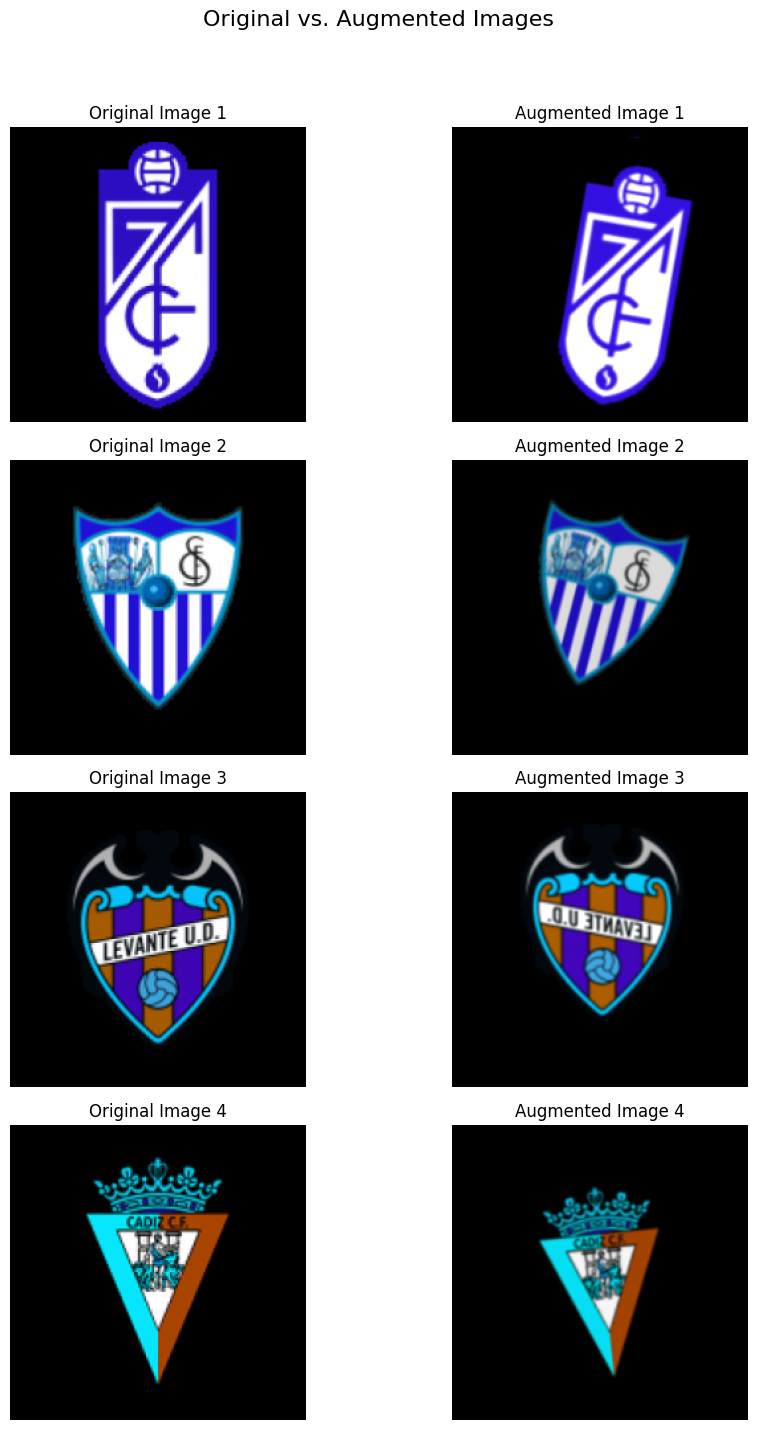

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import cv2

def augment_image_custom(image):

    image = image.astype(np.float32)


    if np.random.rand() < 0.5:
        image = cv2.flip(image, 1)
    if np.random.rand() < 0.2:
        image = cv2.flip(image, 0)


    h, w, _ = image.shape
    center = (w / 2, h / 2)


    angle = np.random.uniform(-25, 25)
    M_rotate = cv2.getRotationMatrix2D(center, angle, 1.0)
    image = cv2.warpAffine(image, M_rotate, (w, h), borderMode=cv2.BORDER_REFLECT_101)


    scale = np.random.uniform(0.8, 1.2)
    M_scale = cv2.getRotationMatrix2D(center, 0, scale)
    image = cv2.warpAffine(image, M_scale, (w, h), borderMode=cv2.BORDER_REFLECT_101)


    tx = np.random.uniform(-0.1, 0.1) * w
    ty = np.random.uniform(-0.1, 0.1) * h
    M_translate = np.float32([[1, 0, tx], [0, 1, ty]])
    image = cv2.warpAffine(image, M_translate, (w, h), borderMode=cv2.BORDER_REFLECT_101)


    brightness_factor = np.random.uniform(0.8, 1.2)
    image = np.clip(image * brightness_factor, 0, 1) # Clip to 0-1 range after brightness adj

    return image.astype(np.float32)


augmented_images = []
for img in normalized_images:
    augmented_images.append(augment_image_custom(img))

print(f"Generated {len(augmented_images)} augmented images.")


fig, axes = plt.subplots(4, 2, figsize=(10, 15))
fig.suptitle('Original vs. Augmented Images', fontsize=16)

for i in range(4):

    axes[i, 0].imshow(normalized_images[i])
    axes[i, 0].set_title(f'Original Image {i+1}')
    axes[i, 0].axis('off')


    display_img = augmented_images[i]
    if display_img.ndim == 2:
        axes[i, 1].imshow(display_img, cmap='gray')
    else:
        axes[i, 1].imshow(display_img)
    axes[i, 1].set_title(f'Augmented Image {i+1}')
    axes[i, 1].axis('off')

plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()

### Create a reusable `preprocess_image` function

In [ ]:
import cv2
import numpy as np

def preprocess_image(image, target_size=(224, 224)):
    """
    Resizes an image and normalizes its pixel values to the 0-1 range.

    Args:
        image (np.ndarray): The input image (OpenCV BGR format).
        target_size (tuple): The desired output size (width, height).

    Returns:
        np.ndarray: The preprocessed image with pixel values in [0, 1].
    """

    resized_img = cv2.resize(image, target_size, interpolation=cv2.INTER_AREA)


    normalized_img = resized_img.astype('float32') / 255.0

    return normalized_img

print("preprocess_image function defined.")

preprocess_image function defined.


### Demonstrate `preprocess_image` function

In [ ]:


if len(images) > 0:
    sample_original_image = images[0]
    preprocessed_sample = preprocess_image(sample_original_image)

    print(f"Original image shape: {sample_original_image.shape}")
    print(f"Preprocessed image shape: {preprocessed_sample.shape}")
    print(f"Preprocessed image Min Value: {preprocessed_sample.min():.2f}")
    print(f"Preprocessed image Max Value: {preprocessed_sample.max():.2f}")
else:
    print("No original images found to demonstrate preprocessing.")

Original image shape: (150, 150, 3)
Preprocessed image shape: (224, 224, 3)
Preprocessed image Min Value: 0.00
Preprocessed image Max Value: 1.00
